In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [15]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [16]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'Churn']]

,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


In [17]:
df = df.dropna(subset=['TotalCharges'])

In [19]:
df.shape

(7032, 21)

In [20]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [21]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


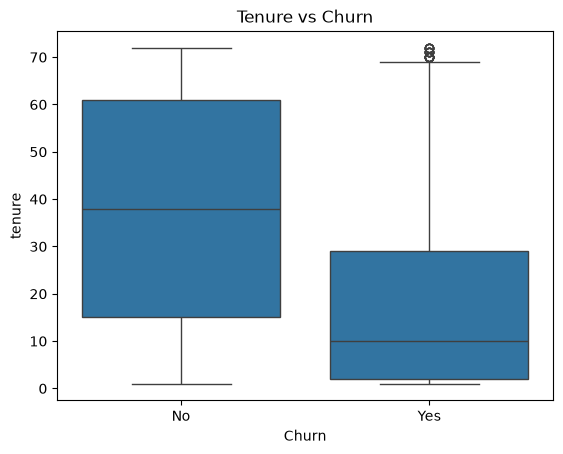

In [22]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

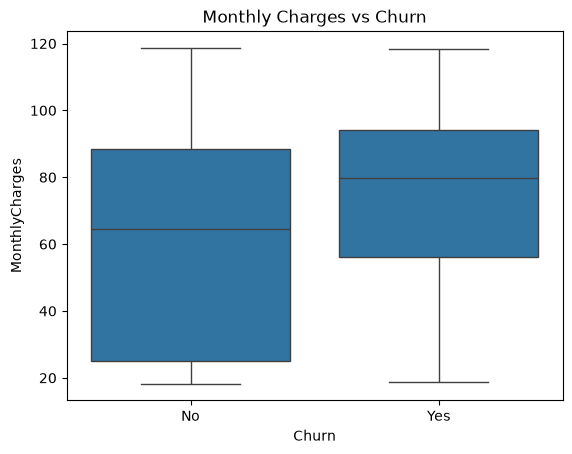

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

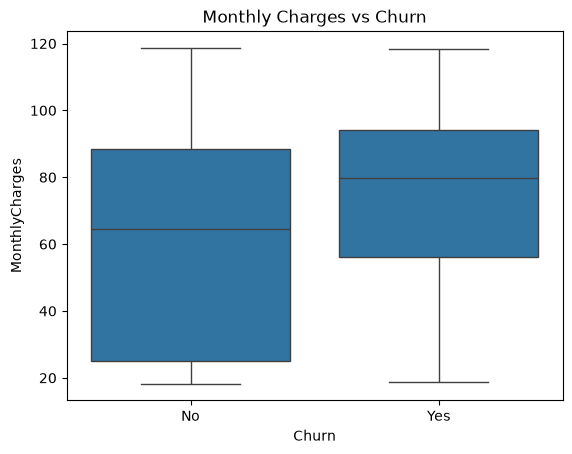

In [24]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

In [25]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [26]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [27]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [29]:
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

In [30]:
X.shape, y.shape

((7032, 19), (7032,))

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [34]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 19), (1407, 19), (5625,), (1407,))

In [36]:
categorical_columns = X_train.select_dtypes(include=['str', 'object']).columns
numerical_columns = X_train.select_dtypes(exclude=['str', 'object']).columns

In [37]:
categorical_columns, numerical_columns

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='str'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str'))

In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [40]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_columns),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)])

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)

In [42]:
X_test_processed = preprocessor.transform(X_test)

In [45]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_processed, y_train)
logistic_predictions = logistic_model.predict(X_test_processed)

In [46]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train_processed, y_train)
decision_tree_predictions = decision_tree_model.predict(X_test_processed)

In [47]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)

random_forest_model.fit(X_train_processed, y_train)
random_forest_predictions = random_forest_model.predict(X_test_processed)

In [48]:
# K-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_processed, y_train)
knn_predictions = knn_model.predict(X_test_processed)

In [49]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(random_state=42)

gradient_boosting_model.fit(X_train_processed, y_train)
gradient_boosting_predictions = gradient_boosting_model.predict(X_test_processed)

In [51]:
# Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': logistic_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions,
    'KNN': knn_predictions,
    'Gradient Boosting': gradient_boosting_predictions
}

results = []

for model_name, predictions in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, pos_label='Yes'),
        'Recall': recall_score(y_test, predictions, pos_label='Yes'),
        'F1 Score': f1_score(y_test, predictions, pos_label='Yes')
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.787491,0.620579,0.516043,0.563504
1,Decision Tree,0.722814,0.479167,0.491979,0.485488
2,Random Forest,0.777541,0.607018,0.462567,0.525038
3,KNN,0.754087,0.539326,0.513369,0.526027
4,Gradient Boosting,0.788913,0.629630,0.500000,0.557377


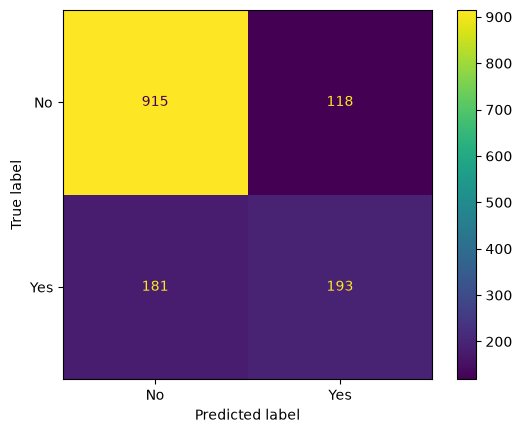

In [52]:
# Confusion Matrix - Logistic Regression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, logistic_predictions, labels=['No', 'Yes'])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes'])

display.plot()

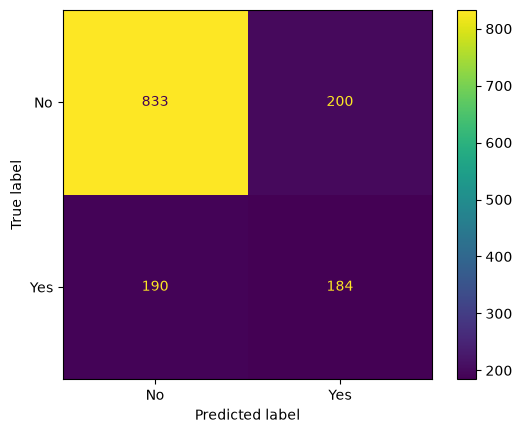

In [53]:
# Confusion Matrix - Decision Tree

cm = confusion_matrix(y_test, decision_tree_predictions, labels=['No', 'Yes'])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

display.plot()

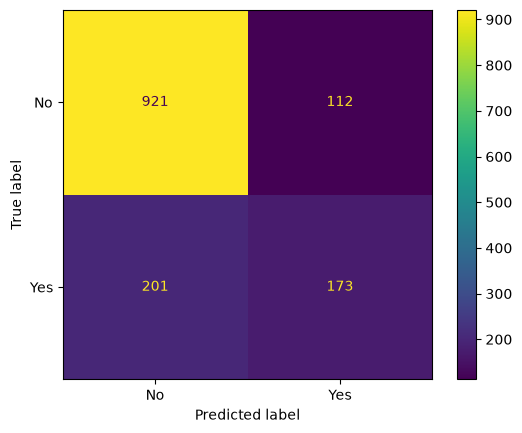

In [54]:
# Confusion Matrix - Random Forest

cm = confusion_matrix(y_test, random_forest_predictions, labels=['No', 'Yes'])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

display.plot()

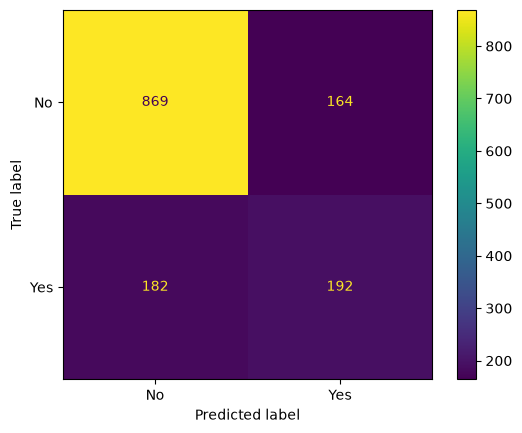

In [55]:
# Confusion Matrix - KNN

cm = confusion_matrix(y_test, knn_predictions, labels=['No', 'Yes'])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

display.plot()

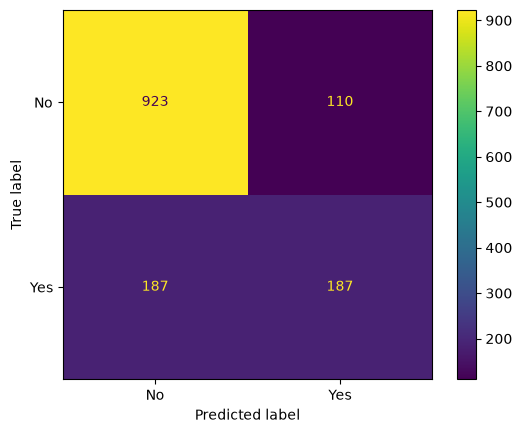

In [56]:
# Confusion Matrix - Gradient Boosting

cm = confusion_matrix(y_test, gradient_boosting_predictions, labels=['No', 'Yes'])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

display.plot()

In [57]:
# Classification Report - Logistic Regression

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    logistic_predictions
))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [58]:
# Classification Reports - All Models

from sklearn.metrics import classification_report

models = {
    'Logistic Regression': logistic_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions,
    'KNN': knn_predictions,
    'Gradient Boosting': gradient_boosting_predictions
}

for model_name, predictions in models.items():
    print(f"\n{'=' * 50}")
    print(model_name)
    print('=' * 50)
    print(classification_report(y_test, predictions))


Logistic Regression
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Decision Tree
              precision    recall  f1-score   support

          No       0.81      0.81      0.81      1033
         Yes       0.48      0.49      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.72      0.72      1407


Random Forest
              precision    recall  f1-score   support

          No       0.82      0.89      0.85      1033
         Yes       0.61      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76

In [60]:
# Cross-Validation - Logistic Regression

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

# Tell sklearn that 'Yes' means positive/churn
yes_f1 = make_scorer(f1_score, pos_label='Yes')

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring=yes_f1
)

logistic_cv_scores

array([0.62545455, 0.60759494, 0.57038391, 0.58886894, 0.63405797])

In [61]:
# Average Cross-Validation F1 Score

logistic_cv_mean = logistic_cv_scores.mean()

logistic_cv_mean

np.float64(0.6052720612361134)

In [62]:
# Hyperparameter Tuning - Logistic Regression

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring=yes_f1)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 100}
Best F1 Score: 0.6068358461986177


In [63]:
# Hyperparameter Tuning - Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

decision_tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=yes_f1
)

decision_tree_grid.fit(X_train_processed, y_train)

print("Best Parameters:", decision_tree_grid.best_params_)
print("Best F1 Score:", decision_tree_grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5}
Best F1 Score: 0.619538742203056


In [65]:
# Hyperparameter Tuning - Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

random_forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=yes_f1
)

random_forest_grid.fit(X_train_processed, y_train)

print("Best Parameters:", random_forest_grid.best_params_)
print("Best F1 Score:", random_forest_grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.5889040572828901


In [66]:
# Hyperparameter Tuning - KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring=yes_f1
)

knn_grid.fit(X_train_processed, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best F1 Score: 0.5822440910741338


In [67]:
# Hyperparameter Tuning - Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

gradient_boosting_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=yes_f1
)

gradient_boosting_grid.fit(X_train_processed, y_train)

print("Best Parameters:", gradient_boosting_grid.best_params_)
print("Best F1 Score:", gradient_boosting_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best F1 Score: 0.5982322285431675


In [69]:
# Compare Tuned Models

tuned_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Gradient Boosting'
    ],
    'Best Parameters': [
        grid_search.best_params_,
        decision_tree_grid.best_params_,
        random_forest_grid.best_params_,
        knn_grid.best_params_,
        gradient_boosting_grid.best_params_
    ],
    'Best CV F1 Score': [
        grid_search.best_score_,
        decision_tree_grid.best_score_,
        random_forest_grid.best_score_,
        knn_grid.best_score_,
        gradient_boosting_grid.best_score_
    ]
})

tuned_results

,Model,Best Parameters,Best CV F1 Score
0,Logistic Regression,{'C': 100},0.606836
1,Decision Tree,"{'max_depth': 5, 'min_samples_split': 5}",0.619539
2,Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.588904
3,KNN,"{'n_neighbors': 11, 'weights': 'uniform'}",0.582244
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.598232


In [70]:
print("Logistic:", grid_search.best_score_)
print("Decision Tree:", decision_tree_grid.best_score_)
print("Random Forest:", random_forest_grid.best_score_)
print("KNN:", knn_grid.best_score_)
print("Gradient Boosting:", gradient_boosting_grid.best_score_)

Logistic: 0.6068358461986177
Decision Tree: 0.619538742203056
Random Forest: 0.5889040572828901
KNN: 0.5822440910741338
Gradient Boosting: 0.5982322285431675


In [71]:
# Step 13 - Feature Importance

best_random_forest = random_forest_grid.best_estimator_

feature_importance = best_random_forest.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__tenure,0.135914
3,num__TotalCharges,0.129860
36,cat__Contract_Month-to-month,0.094044
2,num__MonthlyCharges,0.093206
18,cat__OnlineSecurity_No,0.054605
16,cat__InternetService_Fiber optic,0.050576
27,cat__TechSupport_No,0.044536
43,cat__PaymentMethod_Electronic check,0.036839
38,cat__Contract_Two year,0.025453
21,cat__OnlineBackup_No,0.017545


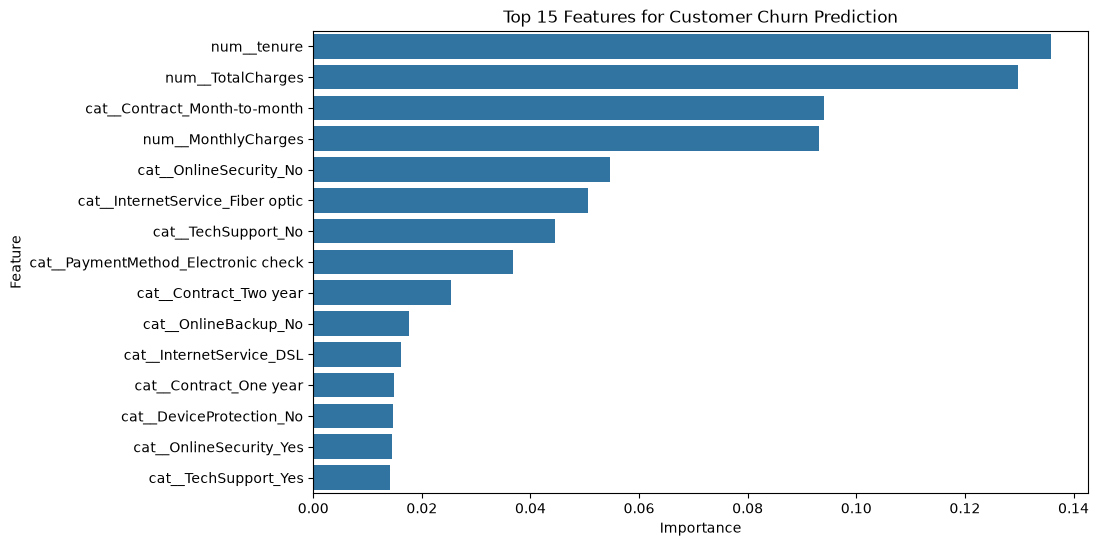

In [72]:
# Feature Importance Visualization

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features for Customer Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [73]:
import joblib

final_model = random_forest_grid.best_estimator_

joblib.dump(final_model, 'churn_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
